In [1]:
import numpy as np
import xarray as xr
import pyart
import datetime
import matplotlib.pyplot as plt
from matplotlib import rc
from matplotlib.ticker import MultipleLocator
import matplotlib.dates as mdates
from matplotlib import cm, colors
import glob
import sys
import os
from grf_functions import *

# plotting set up
plt.rcParams['axes.labelweight'] = 'normal'
plt.rcParams['text.latex.preamble'] = r'\usepackage{bm}'
rc('font', family='sans-serif')
rc('font', weight='normal', size=10)
rc('figure', facecolor='white')
rc('axes', titlesize=15)


## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly
## supported by the U.S. Department of Energy as part of the Atmospheric
## Radiation Measurement (ARM) Climate Research Facility, an Office of
## Science user facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119



In [2]:
# path to radar data
drad = "/data/arrcwx/wrt_jtrf/morton/no_grf/"
# path to output vortex positions
dvort = "/data/arrcwx/wrt_jtrf/morton/sa/"

# read in time-height series
dsn = xr.open_dataset(f"{dvort}vmax_th_no_grf.nc")
dsg = xr.open_dataset(f"{dvort}vmax_th_grf.nc")

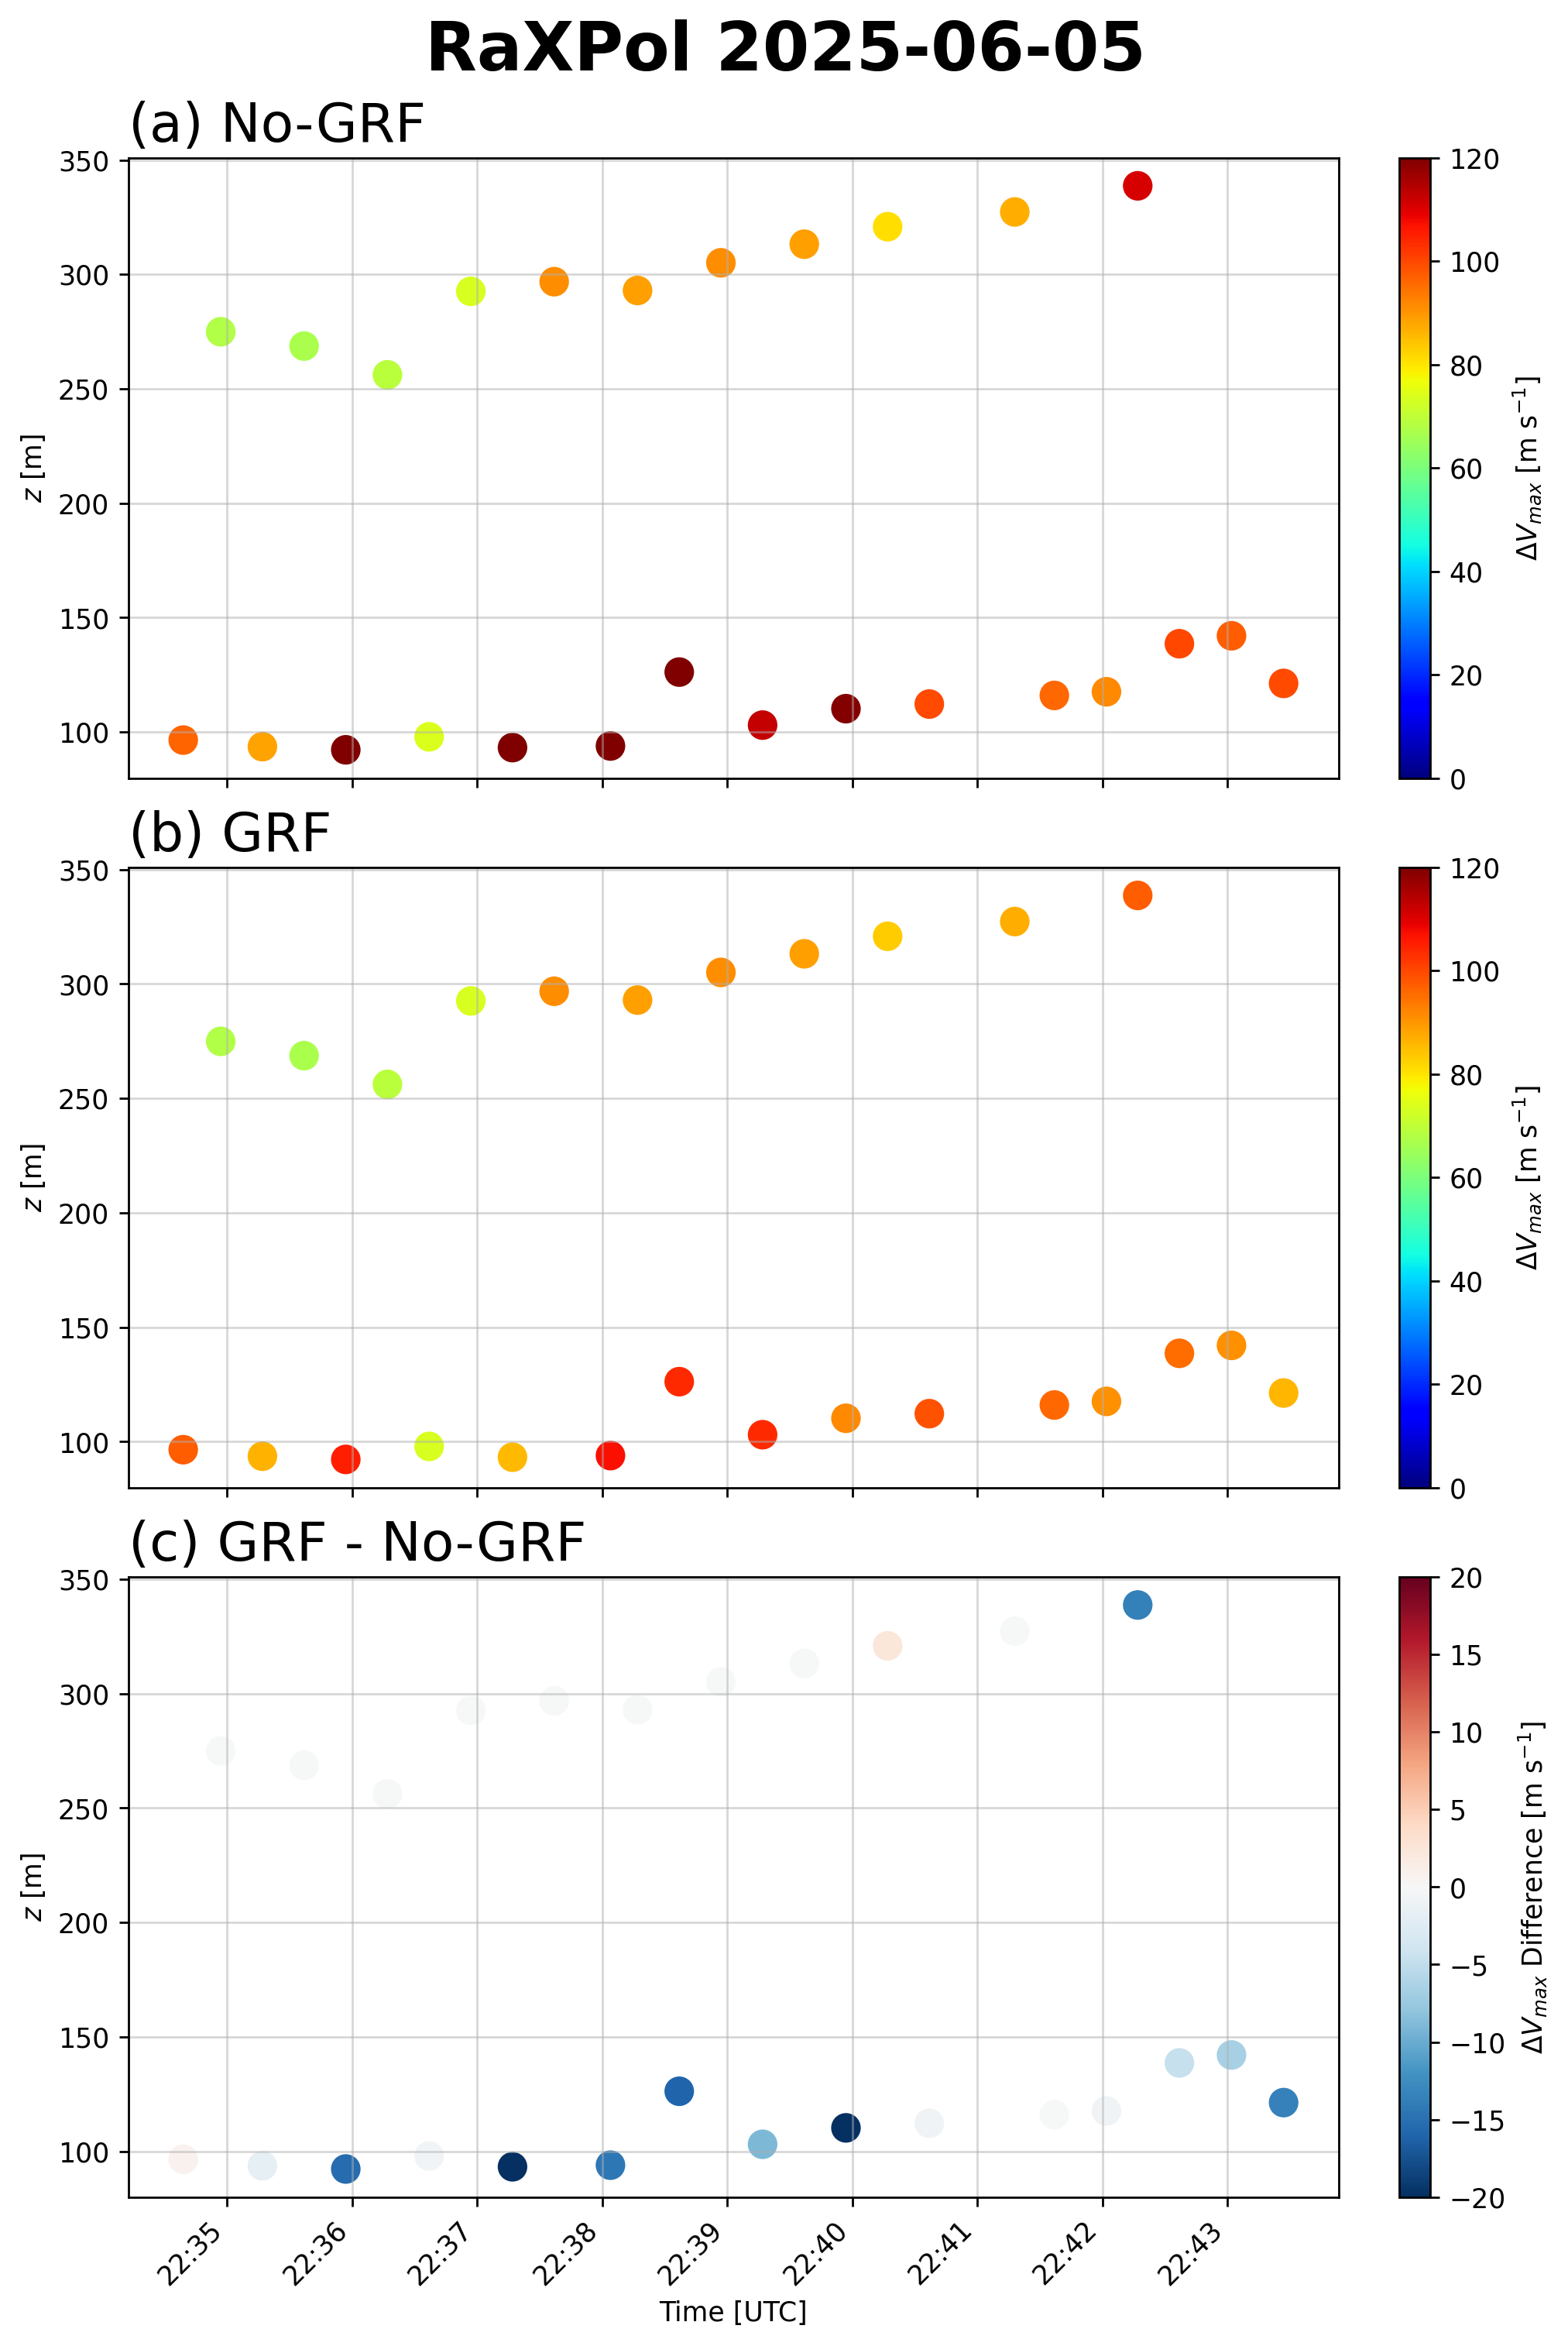

In [5]:
fig, axs = plt.subplots(figsize=(8,12),
                       nrows=3,
                       sharex=True,
                       sharey=True,
                       dpi=250,
                       constrained_layout=True)
fig.suptitle(f"RaXPol {str(dsg.time[0].values)[:10]}",
             fontweight='bold', fontsize=25)

# no grf
ax = axs[0]
sc = ax.scatter(dsn.time, (dsn.zmax + dsn.zmin) / 2, 
                c=dsn.deltav, 
                cmap='jet',
                vmin=0, vmax=120,
                s=100)
cbar = plt.colorbar(sc, ax=ax, label='$\Delta V_{max}$ [m s$^{-1}$]')
ax.set_title("(a) No-GRF", fontsize=20, loc='left')

# grf
ax = axs[1]
sc = ax.scatter(dsg.time, (dsg.zmax + dsg.zmin) / 2,
                c=dsg.deltav, 
                cmap='jet',
                vmin=0, vmax=120,
                s=100)
cbar = plt.colorbar(sc, ax=ax, label='$\Delta V_{max}$ [m s$^{-1}$]')
ax.set_title("(b) GRF", fontsize=20, loc='left')

# difference
ax = axs[2]
zfull = np.array([dsg.zmax.values, dsg.zmin.values, dsn.zmax.values, dsn.zmin.values])
zmean = np.nanmean(zfull, axis=0)
sc = ax.scatter(dsg.time, 
                zmean,
                c=dsg.deltav - dsn.deltav,
                cmap='RdBu_r',
                vmin=-20, vmax=20,
                s=100)
cbar = plt.colorbar(sc, ax=ax, label='$\Delta V_{max}$ Difference [m s$^{-1}$]')
ax.set_title("(c) GRF - No-GRF", fontsize=20, loc='left')
ax.set_xlabel("Time [UTC]")

for ax in axs:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
    ax.set_ylabel("$z$ [m]")
    ax.grid(alpha=0.5)

In [4]:
np.where(dsn.deltav.values > 120)

(array([ 4,  8, 10]),)